# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report,
                             mean_absolute_error,
                             mean_squared_error,
                             r2_score)
import pickle
import os

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


# Dataset Load

In [2]:
df = pd.read_csv('../data/processed/gigsmart_dataset.csv')
print("Dataset loaded ✅")
print("Shape:", df.shape)
df.head(3)

Dataset loaded ✅
Shape: (45593, 16)


,hour,day_of_week,is_weekend,is_festival,weather,zone_type,is_lunch_time,is_dinner_time,distance_km,estimated_time_min,app_name,expected_payout,fuel_cost,time_cost,net_profit,best_app
0,11,5,1,0,clear,normal,0,0,4.2,24,Swiggy,101.55,21.0,36.0,44.55,Swiggy
1,19,4,0,0,rain,low,0,1,14.5,33,Blinkit,220.01,72.5,49.5,98.01,Swiggy
2,8,5,1,0,fog,normal,0,0,6.4,26,Blinkit,104.92,32.0,39.0,33.92,Swiggy


# Encoding

In [3]:
# One Hot Encoding — weather aur zone_type
df_encoded = pd.get_dummies(
    df,
    columns=['weather', 'zone_type'],
    prefix=['weather', 'zone']
)

# Target variable encode karo
le_target = LabelEncoder()
df_encoded['best_app'] = le_target.fit_transform(df['best_app'])

print("Target classes:", le_target.classes_)
# Blinkit=0, Swiggy=1, Zomato=2

print("\nEncoding done ✅")
print("Shape after encoding:", df_encoded.shape)
print("Columns:", df_encoded.columns.tolist())

Target classes: ['Blinkit' 'Swiggy' 'Zomato']

Encoding done ✅
Shape after encoding: (45593, 20)
Columns: ['hour', 'day_of_week', 'is_weekend', 'is_festival', 'is_lunch_time', 'is_dinner_time', 'distance_km', 'estimated_time_min', 'app_name', 'expected_payout', 'fuel_cost', 'time_cost', 'net_profit', 'best_app', 'weather_clear', 'weather_fog', 'weather_rain', 'zone_busy', 'zone_low', 'zone_normal']


# Feature Scaling

In [4]:
# ── CLASSIFICATION FEATURES ──────────────────────
# app_name REMOVE — direct leakage
# expected_payout, fuel_cost, time_cost REMOVE
# net_profit REMOVE — dusra target hai

class_features = [
    'hour', 'day_of_week', 'is_weekend',
    'is_festival', 'is_lunch_time', 'is_dinner_time',
    'distance_km', 'estimated_time_min',
    'weather_clear', 'weather_fog', 'weather_rain',
    'zone_busy', 'zone_low', 'zone_normal'
]

# ── REGRESSION FEATURES ──────────────────────────
# expected_payout, fuel_cost, time_cost REMOVE
# kyunki net_profit = payout - fuel - time
# → formula memorize ho jaata hai
# app_name, best_app REMOVE

reg_features = [
    'hour', 'day_of_week', 'is_weekend',
    'is_festival', 'is_lunch_time', 'is_dinner_time',
    'distance_km', 'estimated_time_min',
    'weather_clear', 'weather_fog', 'weather_rain',
    'zone_busy', 'zone_low', 'zone_normal'
]

# Features aur targets set karo
X_class = df_encoded[class_features]
y_class = df_encoded['best_app']

X_reg = df_encoded[reg_features]
y_reg = df_encoded['net_profit']

print("Classification features:", X_class.columns.tolist())
print("\nClassification target distribution:")
print(y_class.value_counts())
print("\nRegression target stats:")
print(y_reg.describe().round(2))

Classification features: ['hour', 'day_of_week', 'is_weekend', 'is_festival', 'is_lunch_time', 'is_dinner_time', 'distance_km', 'estimated_time_min', 'weather_clear', 'weather_fog', 'weather_rain', 'zone_busy', 'zone_low', 'zone_normal']

Classification target distribution:
best_app
0    16007
2    15794
1    13792
Name: count, dtype: int64

Regression target stats:
count    45593.00
mean        43.54
std         26.40
min        -28.90
25%         24.51
50%         41.48
75%         60.99
max        134.97
Name: net_profit, dtype: float64


# Train Test Split

In [5]:
# Classification split — 80/20
X_train_class, X_test_class, \
y_train_class, y_test_class = train_test_split(
    X_class, y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

# Regression split — 80/20
X_train_reg, X_test_reg, \
y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.20,
    random_state=42
)

print("Classification Split:")
print(f"Train: {X_train_class.shape}")
print(f"Test : {X_test_class.shape}")
print("\nRegression Split:")
print(f"Train: {X_train_reg.shape}")
print(f"Test : {X_test_reg.shape}")

Classification Split:
Train: (36474, 14)
Test : (9119, 14)

Regression Split:
Train: (36474, 14)
Test : (9119, 14)


# Scaling

In [6]:
scaler = StandardScaler()

# Classification scaling
X_train_class_scaled = scaler.fit_transform(X_train_class)
X_test_class_scaled  = scaler.transform(X_test_class)

# Regression scaling
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled  = scaler.transform(X_test_reg)

print("Scaling done ✅")

Scaling done ✅


# Classification

In [7]:
# ── 3 Classification Models ──────────────────────

clf_results = {}

# 1. Logistic Regression (scaled data use karo)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_class_scaled, y_train_class)
y_pred_lr = lr.predict(X_test_class_scaled)

clf_results['Logistic Regression'] = {
    'Accuracy' : accuracy_score(y_test_class, y_pred_lr),
    'Precision': precision_score(y_test_class, y_pred_lr,
                                  average='weighted',
                                  zero_division=0),
    'Recall'   : recall_score(y_test_class, y_pred_lr,
                               average='weighted'),
    'F1 Score' : f1_score(y_test_class, y_pred_lr,
                           average='weighted')
}

# 2. Decision Tree
dt_clf = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt_clf.fit(X_train_class, y_train_class)
y_pred_dt = dt_clf.predict(X_test_class)

clf_results['Decision Tree'] = {
    'Accuracy' : accuracy_score(y_test_class, y_pred_dt),
    'Precision': precision_score(y_test_class, y_pred_dt,
                                  average='weighted',
                                  zero_division=0),
    'Recall'   : recall_score(y_test_class, y_pred_dt,
                               average='weighted'),
    'F1 Score' : f1_score(y_test_class, y_pred_dt,
                           average='weighted')
}

# 3. Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_clf.fit(X_train_class, y_train_class)
y_pred_rf = rf_clf.predict(X_test_class)

clf_results['Random Forest'] = {
    'Accuracy' : accuracy_score(y_test_class, y_pred_rf),
    'Precision': precision_score(y_test_class, y_pred_rf,
                                  average='weighted',
                                  zero_division=0),
    'Recall'   : recall_score(y_test_class, y_pred_rf,
                               average='weighted'),
    'F1 Score' : f1_score(y_test_class, y_pred_rf,
                           average='weighted')
}

# Results print karo
clf_df = pd.DataFrame(clf_results).T.round(4)
print("=" * 55)
print("CLASSIFICATION RESULTS")
print("=" * 55)
print(clf_df)

CLASSIFICATION RESULTS
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9999     0.9999  0.9999    0.9999
Decision Tree          0.9999     0.9999  0.9999    0.9999
Random Forest          0.9999     0.9999  0.9999    0.9999


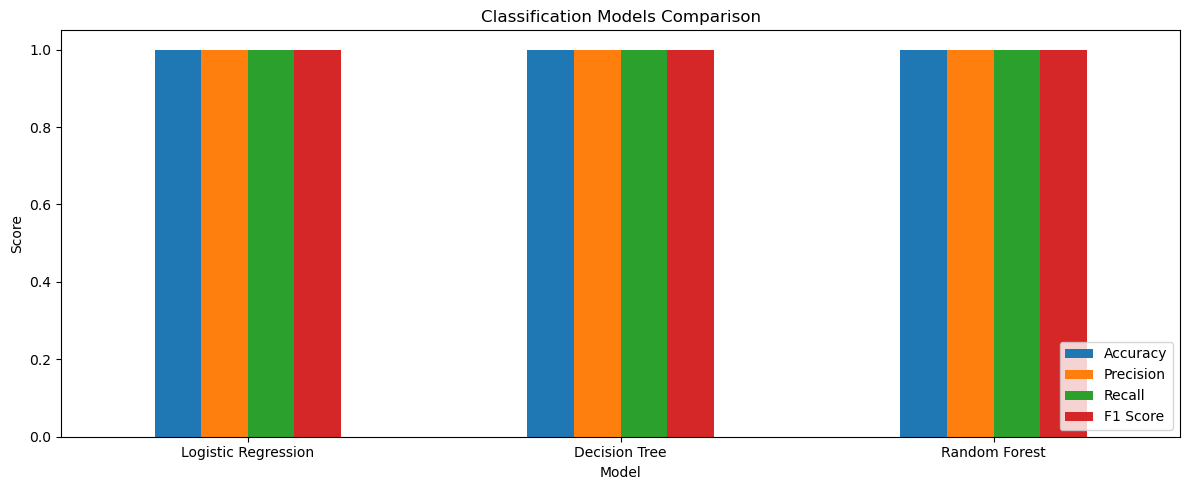


Best Classification Model: Logistic Regression
Accuracy: 0.9999


In [8]:
clf_df.plot(kind='bar', figsize=(12, 5))
plt.title('Classification Models Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Best model
best_clf_name = clf_df['Accuracy'].idxmax()
print(f"\nBest Classification Model: {best_clf_name}")
print(f"Accuracy: {clf_df.loc[best_clf_name, 'Accuracy']:.4f}")

# Regression

In [9]:
# ── 3 Regression Models ──────────────────────────

reg_results = {}

# 1. Linear Regression (scaled data)
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_reg_scaled)

reg_results['Linear Regression'] = {
    'MAE' : mean_absolute_error(y_test_reg, y_pred_lin),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_lin)),
    'R2'  : r2_score(y_test_reg, y_pred_lin)
}

# 2. Decision Tree Regressor
dt_reg = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt_reg.fit(X_train_reg, y_train_reg)
y_pred_dt_reg = dt_reg.predict(X_test_reg)

reg_results['Decision Tree'] = {
    'MAE' : mean_absolute_error(y_test_reg, y_pred_dt_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg,
                                        y_pred_dt_reg)),
    'R2'  : r2_score(y_test_reg, y_pred_dt_reg)
}

# 3. Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

reg_results['Random Forest'] = {
    'MAE' : mean_absolute_error(y_test_reg, y_pred_rf_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg,
                                        y_pred_rf_reg)),
    'R2'  : r2_score(y_test_reg, y_pred_rf_reg)
}

# Results print karo
reg_df = pd.DataFrame(reg_results).T.round(4)
print("=" * 45)
print("REGRESSION RESULTS")
print("=" * 45)
print(reg_df)

REGRESSION RESULTS
                      MAE    RMSE      R2
Linear Regression  4.4878  5.3192  0.9594
Decision Tree      2.4645  3.6316  0.9811
Random Forest      1.8409  2.9578  0.9874


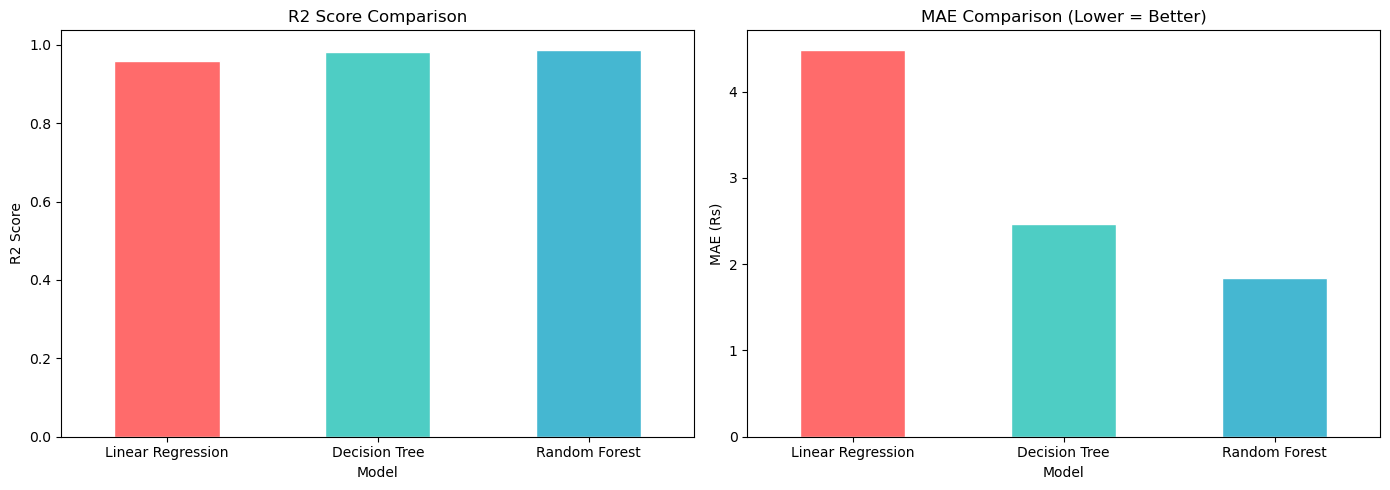


Best Regression Model: Random Forest
R2  : 0.9874
MAE : 1.8409


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 Score
reg_df['R2'].plot(kind='bar', ax=axes[0],
                   color=['#FF6B6B','#4ECDC4','#45B7D1'],
                   edgecolor='white')
axes[0].set_title('R2 Score Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R2 Score')
axes[0].tick_params(axis='x', rotation=0)

# MAE
reg_df['MAE'].plot(kind='bar', ax=axes[1],
                    color=['#FF6B6B','#4ECDC4','#45B7D1'],
                    edgecolor='white')
axes[1].set_title('MAE Comparison (Lower = Better)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MAE (Rs)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

best_reg_name = reg_df['R2'].idxmax()
print(f"\nBest Regression Model: {best_reg_name}")
print(f"R2  : {reg_df.loc[best_reg_name, 'R2']:.4f}")
print(f"MAE : {reg_df.loc[best_reg_name, 'MAE']:.4f}")

In [ ]:
from sklearn.model_selection import cross_val_score

print("=" * 50)
print("CROSS VALIDATION RESULTS (5-Fold)")
print("=" * 50)

# Classification CV
models_clf = {
    'Logistic Regression': lr,
    'Decision Tree'      : dt_clf,
    'Random Forest'      : rf_clf
}

print("\nClassification (best_app):")
for name, model in models_clf.items():
    if name == 'Logistic Regression':
        scores = cross_val_score(
            model, X_class, y_class,
            cv=5, scoring='accuracy'
        )
    else:
        scores = cross_val_score(
            model, X_class, y_class,
            cv=5, scoring='accuracy'
        )
    print(f"{name}:")
    print(f"  Scores : {scores.round(4)}")
    print(f"  Mean   : {scores.mean():.4f}")
    print(f"  Std Dev: {scores.std():.4f}")

# Regression CV
models_reg = {
    'Linear Regression': lin_reg,
    'Decision Tree'    : dt_reg,
    'Random Forest'    : rf_reg
}

print("\nRegression (net_profit):")
for name, model in models_reg.items():
    scores = cross_val_score(
        model, X_reg, y_reg,
        cv=5, scoring='r2'
    )
    print(f"{name}:")
    print(f"  Scores : {scores.round(4)}")
    print(f"  Mean   : {scores.mean():.4f}")
    print(f"  Std Dev: {scores.std():.4f}")

CROSS VALIDATION RESULTS (5-Fold)

Classification (best_app):
Logistic Regression:
  Scores : [1. 1. 1. 1. 1.]
  Mean   : 1.0000
  Std Dev: 0.0000
Decision Tree:
  Scores : [0.9997 0.9998 0.9999 1.     1.    ]
  Mean   : 0.9999
  Std Dev: 0.0001
Random Forest:
  Scores : [0.9999 0.9999 0.9999 1.     1.    ]
  Mean   : 0.9999
  Std Dev: 0.0001

Regression (net_profit):
Linear Regression:
  Scores : [0.9605 0.9608 0.9619 0.96   0.9602]
  Mean   : 0.9607
  Std Dev: 0.0007
Decision Tree:
  Scores : [0.9819 0.9818 0.9823 0.9815 0.9813]
  Mean   : 0.9818
  Std Dev: 0.0003
